In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import spacy

In [91]:
fake  = pd.read_csv('/content/Fake.csv')
real = pd.read_csv('/content/True.csv')

In [92]:
fake.head(5)

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [93]:
real.head(5)

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [94]:
print(fake.shape)
print(real.shape)

(23481, 4)
(21417, 4)


In [95]:
fake['label'] = 0
real['label'] = 1

In [96]:
data = pd.concat([fake,real],ignore_index=True)
data = data.sample(frac=1).reset_index(drop=True)

In [97]:
print(data["label"].value_counts())
data.head()

label
0    23481
1    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,Trump takes center stage in fractious Senate r...,"HUNTSVILLE, Alabama (Reuters) - President Dona...",politicsNews,"September 22, 2017",1
1,Big Corp. Is So Afraid Of A Liberal SCOTUS Th...,It looks like Justice Antonin Scalia s untimel...,News,"February 26, 2016",0
2,"In One Cowardice Move, GOP Congress Just PROV...",In one of his first moves since becoming the P...,News,"November 16, 2016",0
3,"U.S. top court hands win to unions, splits 4-4...",WASHINGTON (Reuters) - Public sector unions tr...,politicsNews,"March 29, 2016",1
4,EPA head seeks to avoid settlements with green...,WASHINGTON (Reuters) - The head of the U.S. En...,politicsNews,"October 16, 2017",1


In [98]:
data["content"] = data["title"] + " " + data["text"]
data = data[["content", "label"]]
data.head()

,content,label
0,Trump takes center stage in fractious Senate r...,1
1,Big Corp. Is So Afraid Of A Liberal SCOTUS Th...,0
2,"In One Cowardice Move, GOP Congress Just PROV...",0
3,"U.S. top court hands win to unions, splits 4-4...",1
4,EPA head seeks to avoid settlements with green...,1


/tmp/ipython-input-3021796952.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='Set2')


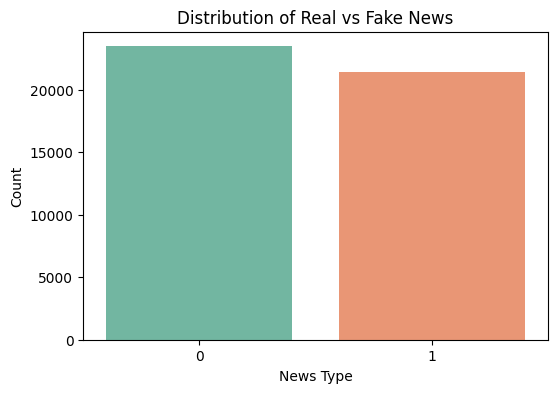

In [99]:
# Count plot
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=data, palette='Set2')

plt.title('Distribution of Real vs Fake News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.show()


In [100]:
import re

def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^A-Za-z\s]", "", text)
    text = text.lower().strip()
    return text

data["content"] = data["content"].apply(clean_text)


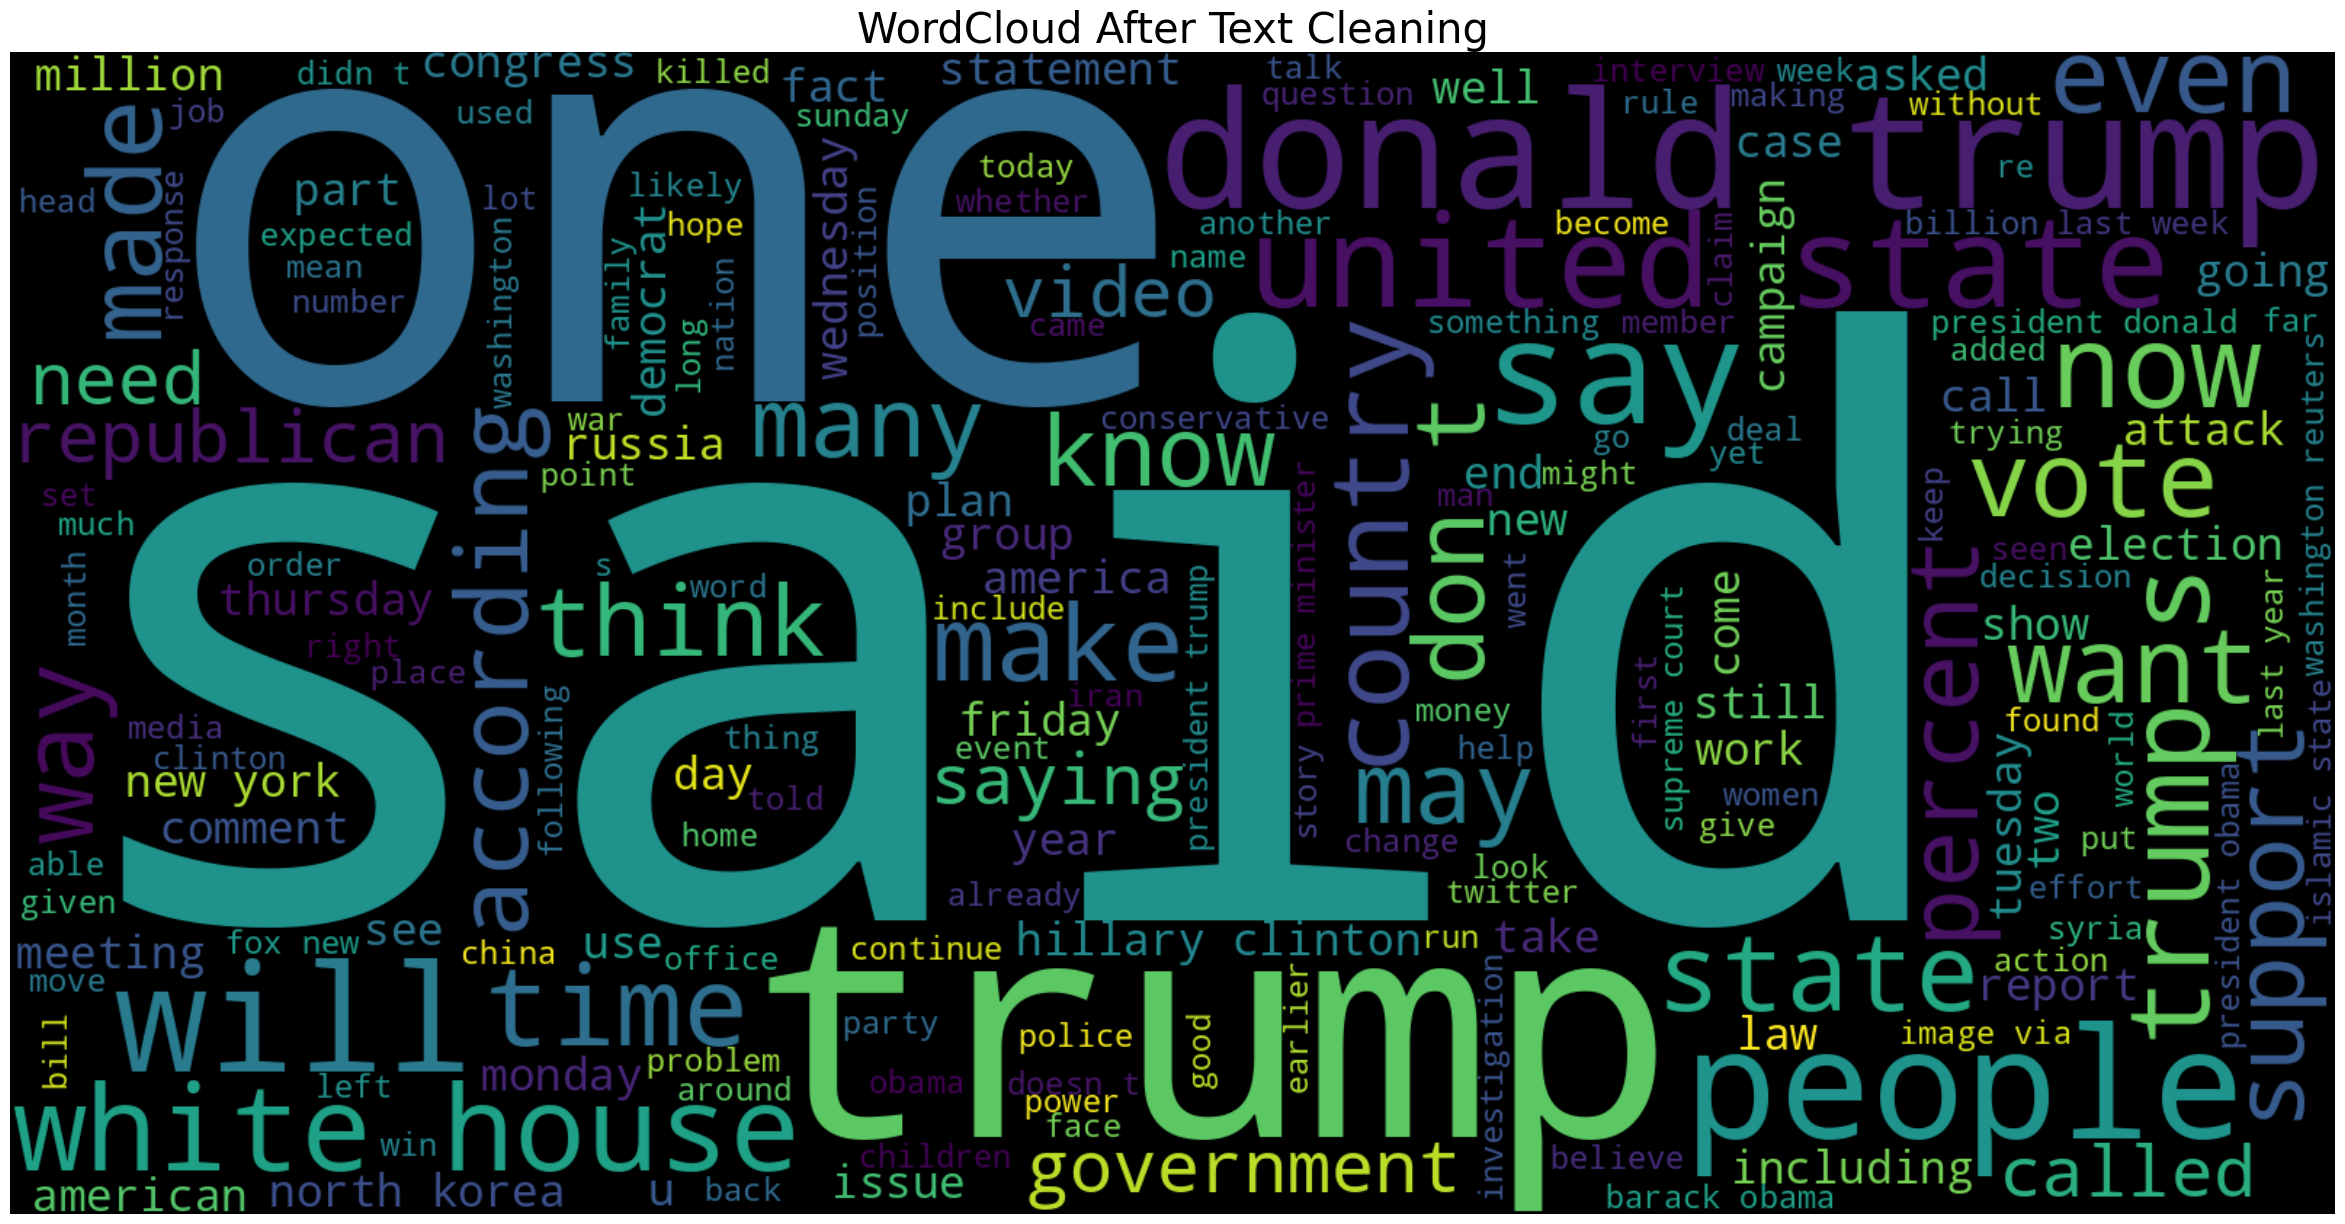

In [101]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

processed_words = []
for txt in data["content"]:
    processed_words.append(txt)

plt.figure(figsize=(30,20))
wc = WordCloud(
    background_color="black",
    width=1600,
    height=800,
    colormap="viridis"
).generate(" ".join(processed_words))

plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("WordCloud After Text Cleaning", fontsize=30)
plt.show()


In [102]:
from sklearn.model_selection import train_test_split

In [103]:
X_train,X_test,y_train,y_test =train_test_split(data['content'],data['label'],test_size=0.2,random_state=42)

In [112]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Vectorize
vectorizer = TfidfVectorizer(max_features=10000, stop_words="english", ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Model
model = LogisticRegression(max_iter=1500)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=1500)

In [114]:
y_pred = model.predict(X_test_vec)



In [115]:
y_pred

array([1, 0, 1, ..., 0, 0, 0])

In [116]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9917594654788419
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4731
           1       0.99      0.99      0.99      4249

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



Text(95.72222222222221, 0.5, 'Truth')

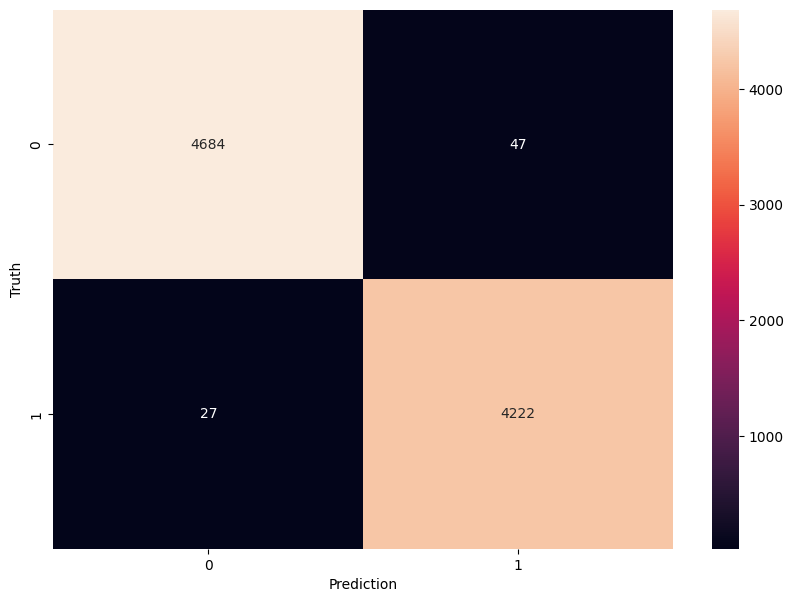

In [117]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (10,7))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Prediction')
plt.ylabel('Truth')

In [118]:
import pickle
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))
pickle.dump(model, open("model.pkl", "wb"))
print("Saved: model.pkl, vectorizer.pkl")


Saved: model.pkl, vectorizer.pkl
